### Importación de datos

Objetivo Análisis

Análisis exploratorio de datos de ventas de Alura Store, combinando visualizaciones analíticas, interpretación de métricas de negocio e insights estratégicos para apoyar la toma de decisiones basada en datos.




In [2]:
#Importación de Librerias para la ejecución
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import matplotlib.cm as cm
import numpy as np
import requests
import seaborn as sns

# URL de la API proporcionada por el challenge

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

# Transformación de url
tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:

#Total de ingresos por tienda

ingreso1 = tienda['Precio'].sum()
ingreso2 = tienda2['Precio'].sum()
ingreso3 = tienda3['Precio'].sum()
ingreso4 = tienda4['Precio'].sum()

ingresos = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso1, ingreso2, ingreso3, ingreso4]
}

ingresos_df = pd.DataFrame(ingresos)

ingresos_df['Ingreso Total'] = ingresos_df['Ingreso Total'].map('{:>15,.2f}'.format)

print(ingresos_df)



     Tienda     Ingreso Total
0  Tienda 1  1,150,880,400.00
1  Tienda 2  1,116,343,500.00
2  Tienda 3  1,098,019,600.00
3  Tienda 4  1,038,375,700.00


In [31]:
# Crear DataFrame con ingresos sin formatear para cálculos
ingresos_num = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso1, ingreso2, ingreso3, ingreso4]
})
# Tienda con mayor ingreso
max_ingreso = ingresos_num['Ingreso Total'].max()
tienda_max = ingresos_num.loc[ingresos_num['Ingreso Total'] == max_ingreso, 'Tienda'].values[0]

# Tienda con menor ingreso
min_ingreso = ingresos_num['Ingreso Total'].min()
tienda_min = ingresos_num.loc[ingresos_num['Ingreso Total'] == min_ingreso, 'Tienda'].values[0]

# Diferencia
diferencia = max_ingreso - min_ingreso
print(f"La tienda con mayor ingreso es {tienda_max} con ${max_ingreso:,.2f}")
print(f"La tienda con menor ingreso es {tienda_min} con ${min_ingreso:,.2f}")
print(f"La diferencia entre ambas es ${diferencia:,.2f}")

La tienda con mayor ingreso es Tienda 1 con $1,150,880,400.00
La tienda con menor ingreso es Tienda 4 con $1,038,375,700.00
La diferencia entre ambas es $112,504,700.00


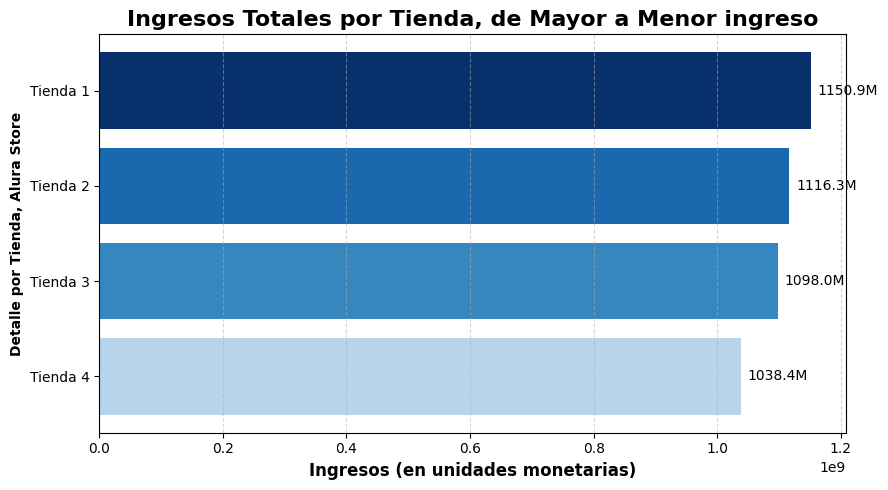

In [4]:
# Gráfico de barra para mostrar total de ventas por tienda
ingresos = [
    tienda['Precio'].sum(),
    tienda2['Precio'].sum(),
    tienda3['Precio'].sum(),
    tienda4['Precio'].sum()
]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

## Normalizar ingresos entre 0.3 y 1 para que no sea demasiado claro
norm = (np.array(ingresos) - np.min(ingresos)) / (np.max(ingresos) - np.min(ingresos))
norm = 0.3 + 0.7 * norm  # escala de 0.3 a 1

# Colormap
cmap = cm.Blues
colors = cmap(norm)

# Crear gráfico
plt.figure(figsize=(9,5))
bars = plt.barh(nombres_tiendas, ingresos, color=colors)

# Títulos y ejes
plt.title('Ingresos Totales por Tienda, de Mayor a Menor ingreso', fontsize=16, fontweight='bold')
plt.ylabel('Tiendas', fontsize=14, fontweight='bold')  # Eje y
plt.xlabel('Ingresos (en unidades monetarias)', fontsize=12, fontweight='bold')  # Eje x
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.ylabel('Detalle por Tienda, Alura Store', fontsize=10, fontweight='bold')  # Eje y
plt.xlabel('Ingresos (en unidades monetarias)', fontsize=12, fontweight='bold')
# Etiquetas sobre las barras
for bar, ingreso in zip(bars, ingresos):
    plt.text(bar.get_width() + bar.get_width()*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{ingreso/1e6:.1f}M',
             va='center')


plt.tight_layout()
plt.savefig('Ingresos_totales_por_tienda_DMM.png')
plt.show()

# 2. Ventas por categoría

In [5]:
#Contar productos por categoria, ordena por cantidad y tienda.
def contar_productos_por_categoria(df, nombre_tienda):
    conteo = df['Categoría del Producto'].value_counts().reset_index()
    conteo.columns = ['Categoría', 'Cantidad Vendida']
    conteo['Tienda'] = nombre_tienda
    return conteo

categorias_tienda = contar_productos_por_categoria(tienda, 'Tienda 1')
categorias_tienda2 = contar_productos_por_categoria(tienda2, 'Tienda 2')
categorias_tienda3 = contar_productos_por_categoria(tienda3, 'Tienda 3')
categorias_tienda4 = contar_productos_por_categoria(tienda4, 'Tienda 4')

categorias_totales = pd.concat([categorias_tienda, categorias_tienda2, categorias_tienda3, categorias_tienda4])
by=['Tienda','Cantidad']

ascending=[True, False]
print(categorias_totales)

                 Categoría  Cantidad Vendida    Tienda
0                  Muebles               465  Tienda 1
1             Electrónicos               448  Tienda 1
2                 Juguetes               324  Tienda 1
3        Electrodomésticos               312  Tienda 1
4     Deportes y diversión               284  Tienda 1
5   Instrumentos musicales               182  Tienda 1
6                   Libros               173  Tienda 1
7  Artículos para el hogar               171  Tienda 1
0                  Muebles               442  Tienda 2
1             Electrónicos               422  Tienda 2
2                 Juguetes               313  Tienda 2
3        Electrodomésticos               305  Tienda 2
4     Deportes y diversión               275  Tienda 2
5   Instrumentos musicales               224  Tienda 2
6                   Libros               197  Tienda 2
7  Artículos para el hogar               181  Tienda 2
0                  Muebles               499  Tienda 3
1         

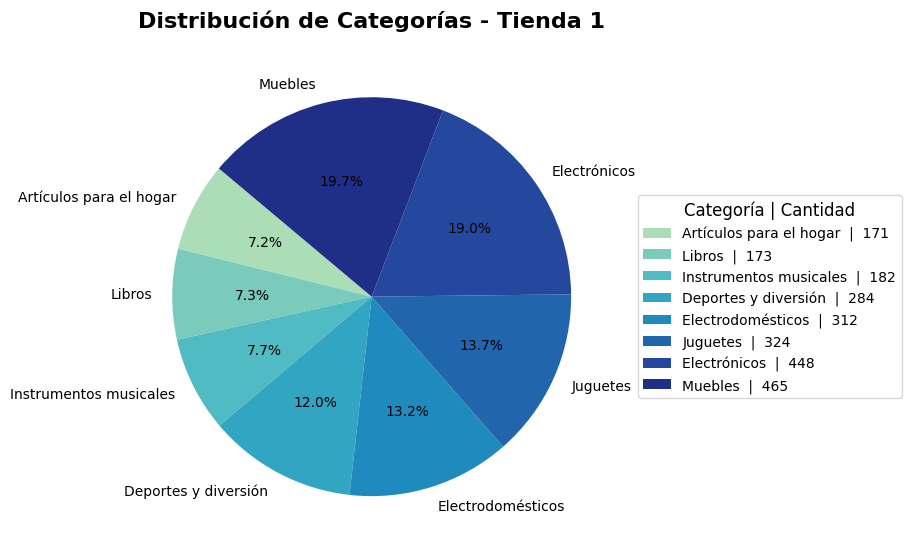


--------------------------------------------------------------------------------



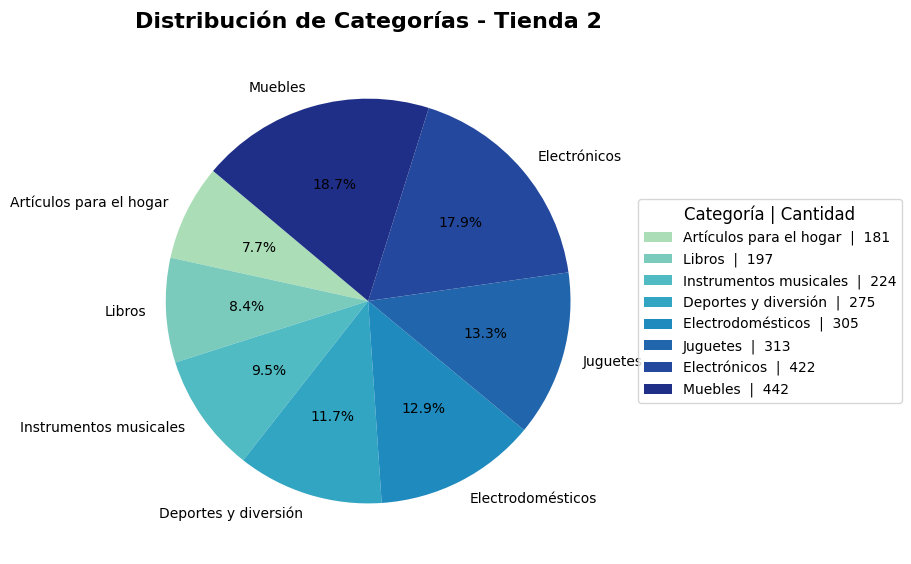


--------------------------------------------------------------------------------



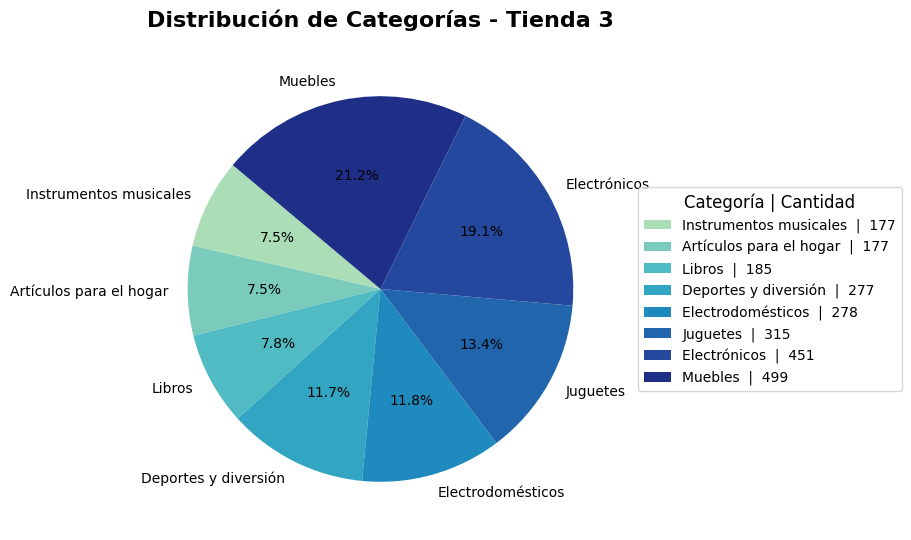


--------------------------------------------------------------------------------



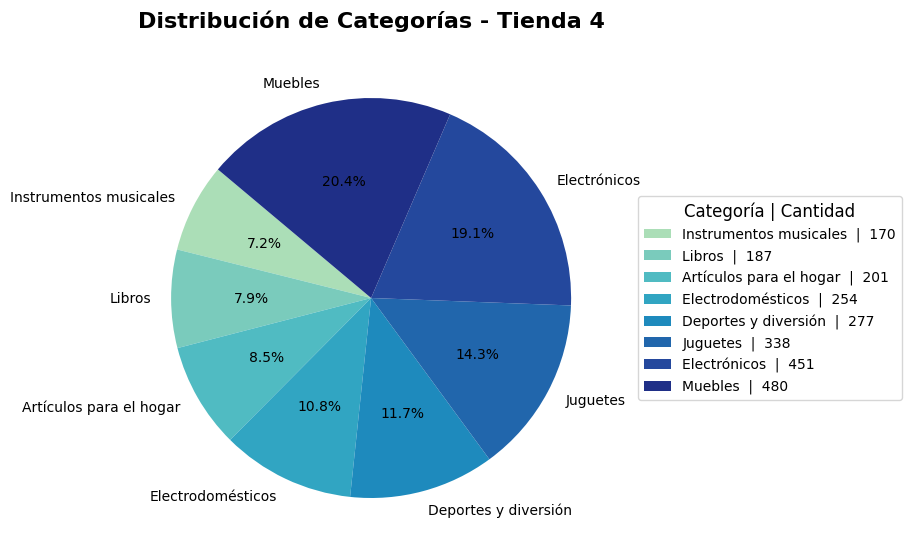


--------------------------------------------------------------------------------



In [6]:
import matplotlib.pyplot as plt
import numpy as np

tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

for df, nombre in zip(tiendas, nombres_tiendas):

    categorias = df['Categoría del Producto'].value_counts()
    categorias = categorias.sort_values()

    # Gradiente verde azulado
    cmap = plt.cm.YlGnBu
    colors = cmap(np.linspace(0.3, 0.9, len(categorias)))

    fig, ax = plt.subplots(figsize=(9,7), constrained_layout=True)

    wedges, texts, autotexts = ax.pie(
        categorias,
        labels=categorias.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        textprops={'fontsize':10}
    )

    ax.set_title(
        f'Distribución de Categorías - {nombre}',
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Texto de la tabla interpretativa
    etiquetas_tabla = [
        f"{cat}  |  {val}"
        for cat, val in zip(categorias.index, categorias.values)
    ]

    ax.legend(
        wedges,
        etiquetas_tabla,
        title="Categoría | Cantidad",
        title_fontsize=12,
        fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    archivo_individual = f'distribucion_categorias_{nombre.lower().replace(" ", "_")}.png'

    plt.savefig(
        archivo_individual,
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("\n" + "-"*80 + "\n")

In [32]:
for df, nombre in zip(tiendas, nombres_tiendas):

    categorias = df['Categoría del Producto'].value_counts()

    print(f"\n{'='*50}")
    print(f"Listado de categorías - {nombre}")
    print(f"{'='*50}")

    for categoria, cantidad in categorias.items():
        print(f"{categoria}: {cantidad}")


Listado de categorías - Tienda 1
Muebles: 465
Electrónicos: 448
Juguetes: 324
Electrodomésticos: 312
Deportes y diversión: 284
Instrumentos musicales: 182
Libros: 173
Artículos para el hogar: 171

Listado de categorías - Tienda 2
Muebles: 442
Electrónicos: 422
Juguetes: 313
Electrodomésticos: 305
Deportes y diversión: 275
Instrumentos musicales: 224
Libros: 197
Artículos para el hogar: 181

Listado de categorías - Tienda 3
Muebles: 499
Electrónicos: 451
Juguetes: 315
Electrodomésticos: 278
Deportes y diversión: 277
Libros: 185
Instrumentos musicales: 177
Artículos para el hogar: 177

Listado de categorías - Tienda 4
Muebles: 480
Electrónicos: 451
Juguetes: 338
Deportes y diversión: 277
Electrodomésticos: 254
Artículos para el hogar: 201
Libros: 187
Instrumentos musicales: 170


# 3. Calificación promedio de la tienda


In [7]:
def promedio_calificacion(df):
    return df['Calificación'].mean()

promedio1 = promedio_calificacion(tienda)
promedio2 = promedio_calificacion(tienda2)
promedio3 = promedio_calificacion(tienda3)
promedio4 = promedio_calificacion(tienda4)

promedios = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Promedio de Calificación': [promedio1, promedio2, promedio3, promedio4]
}

promedios_df = pd.DataFrame(promedios)

print(promedios_df)

     Tienda  Promedio de Calificación
0  Tienda 1                  3.976685
1  Tienda 2                  4.037304
2  Tienda 3                  4.048326
3  Tienda 4                  3.995759


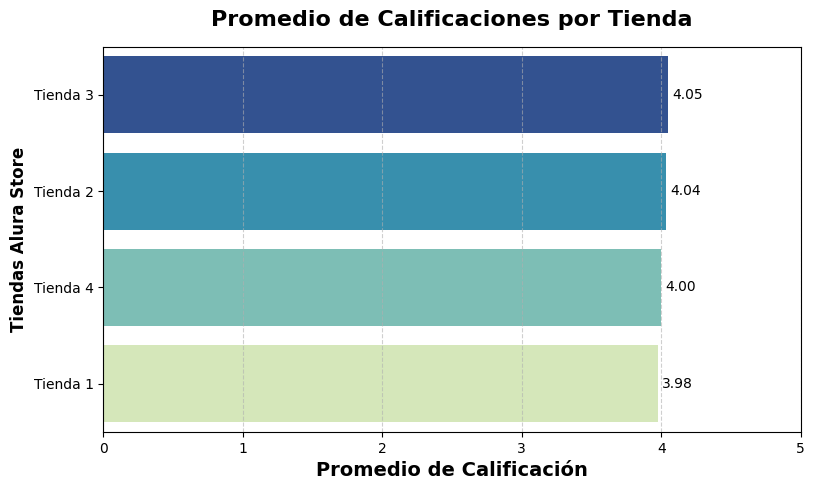

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

promedios_calificacion = [
    tienda['Calificación'].mean(),
    tienda2['Calificación'].mean(),
    tienda3['Calificación'].mean(),
    tienda4['Calificación'].mean()
]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

calificaciones_df = pd.DataFrame({
    'Tiendas Alura Store': nombres_tiendas,
    'Promedio de Calificación': promedios_calificacion
})

# Ordenar de mayor a menor
calificaciones_df = calificaciones_df.sort_values('Promedio de Calificación', ascending=False)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=calificaciones_df,
    y='Tiendas Alura Store',
    x='Promedio de Calificación',
    palette='YlGnBu_r'  # gradiente verde-azulado
)

# Etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3, fontsize=10)

# Títulos y ejes
plt.title('Promedio de Calificaciones por Tienda', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Promedio de Calificación', fontsize=14, fontweight='bold')
plt.ylabel('Tiendas Alura Store', fontsize=12, fontweight='bold')
plt.xlim(0, 5)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Guardar imagen de alta calidad
plt.savefig('Promedio_de_Calificaciones_por_Tienda.png', dpi=400, bbox_inches='tight')

plt.show()
plt.close()

# 4. Productos más y menos vendidos

In [11]:
def productos_extremos(df, nombre_tienda):
    conteo = df['Producto'].value_counts()

    mas_vendido = conteo.idxmax()
    ventas_mas_vendido = conteo.max()

    menos_vendido = conteo.idxmin()
    ventas_menos_vendido = conteo.min()

    print(f"Resumen Productos más y menos vendidos en Alura Store")
    print(f"\n{nombre_tienda}")
    print(f"Producto más vendido: {mas_vendido} ({ventas_mas_vendido} ventas)")
    print(f"Producto menos vendido: {menos_vendido} ({ventas_menos_vendido} ventas)")


productos_extremos(tienda, 'Tienda 1:')
productos_extremos(tienda2, 'Tienda 2:')
productos_extremos(tienda3, 'Tienda 3:')
productos_extremos(tienda4, 'Tienda 4:')

Resumen Productos más y menos vendidos en Alura Store

Tienda 1:
Producto más vendido: Microondas (60 ventas)
Producto menos vendido: Auriculares con micrófono (33 ventas)
Resumen Productos más y menos vendidos en Alura Store

Tienda 2:
Producto más vendido: Iniciando en programación (65 ventas)
Producto menos vendido: Juego de mesa (32 ventas)
Resumen Productos más y menos vendidos en Alura Store

Tienda 3:
Producto más vendido: Kit de bancas (57 ventas)
Producto menos vendido: Bloques de construcción (35 ventas)
Resumen Productos más y menos vendidos en Alura Store

Tienda 4:
Producto más vendido: Cama box (62 ventas)
Producto menos vendido: Guitarra eléctrica (33 ventas)


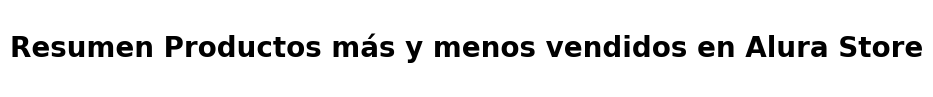

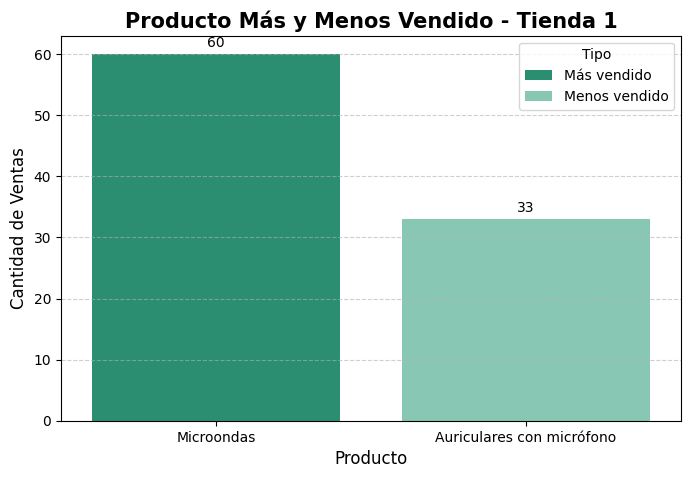

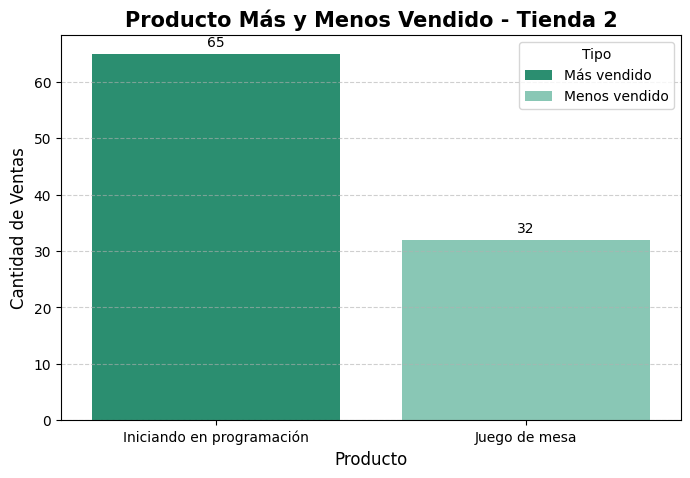

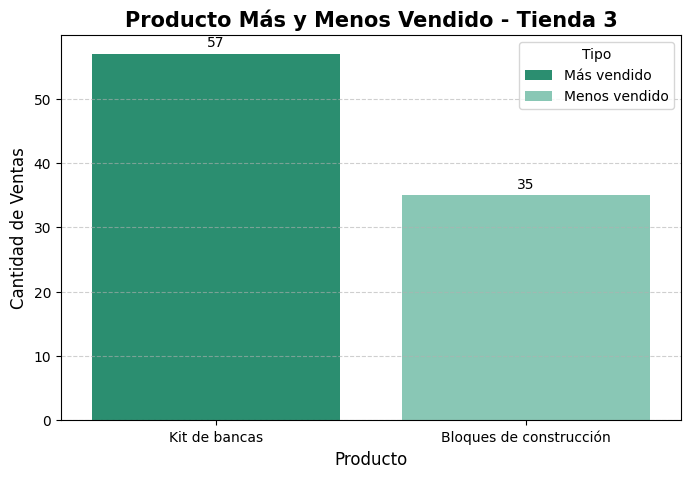

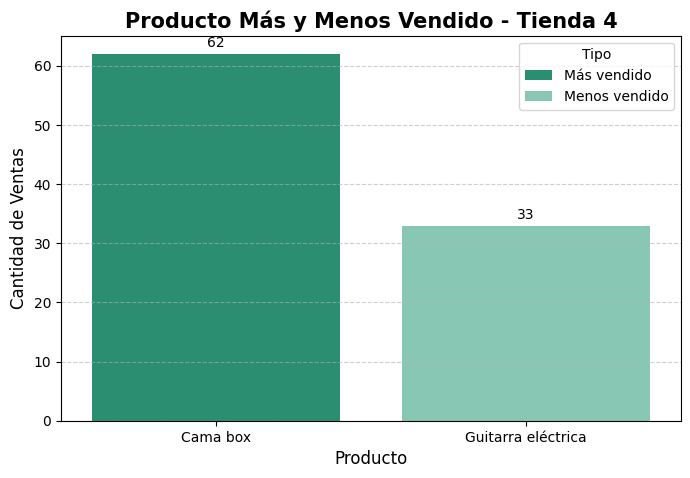

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def grafico_productos_extremos(df, nombre_tienda):

    conteo = df['Producto'].value_counts()

    mas_vendido = conteo.idxmax()
    ventas_mas = conteo.max()

    menos_vendido = conteo.idxmin()
    ventas_menos = conteo.min()

    datos = pd.DataFrame({
        "Producto": [mas_vendido, menos_vendido],
        "Ventas": [ventas_mas, ventas_menos],
        "Tipo": ["Más vendido", "Menos vendido"]
    })

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=datos,
        x="Producto",
        y="Ventas",
        hue="Tipo",
        palette={
            "Más vendido": "#1b9e77",   # verde azulado
            "Menos vendido": "#7fd1b9"  # verde agua
        }
    )

    # Etiquetas con valores
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.title(
        f"Producto Más y Menos Vendido - {nombre_tienda}",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Producto", fontsize=12)
    plt.ylabel("Cantidad de Ventas", fontsize=12)

    plt.grid(axis="y", linestyle="--", alpha=0.6)

    archivo = f"productos_extremos_{nombre_tienda.lower().replace(' ','_')}.png"

    plt.savefig(archivo, dpi=400, bbox_inches="tight")

    plt.show()
    plt.close()

plt.figure(figsize=(10,1))
plt.text(
    0.5, 0.5,
    "Resumen Productos más y menos vendidos en Alura Store",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)
plt.axis("off")
plt.show()
grafico_productos_extremos(tienda, "Tienda 1")
grafico_productos_extremos(tienda2, "Tienda 2")
grafico_productos_extremos(tienda3, "Tienda 3")
grafico_productos_extremos(tienda4, "Tienda 4")

# 5. Envío promedio por tienda

In [14]:
def promedio_costo_envio(df):
    return df['Costo de envío'].mean()

promedio_envio1 = promedio_costo_envio(tienda)
promedio_envio2 = promedio_costo_envio(tienda2)
promedio_envio3 = promedio_costo_envio(tienda3)
promedio_envio4 = promedio_costo_envio(tienda4)

costos_envio = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Costo de Envío Promedio': [promedio_envio1, promedio_envio2, promedio_envio3, promedio_envio4]
}

costos_envio_df = pd.DataFrame(costos_envio)
print(f"Resumen de Costo de envió promedio por tienda en Alura Store")

print(costos_envio_df)

Resumen de Costo de envió promedio por tienda en Alura Store
     Tienda  Costo de Envío Promedio
0  Tienda 1             26018.609580
1  Tienda 2             25216.235693
2  Tienda 3             24805.680373
3  Tienda 4             23459.457167


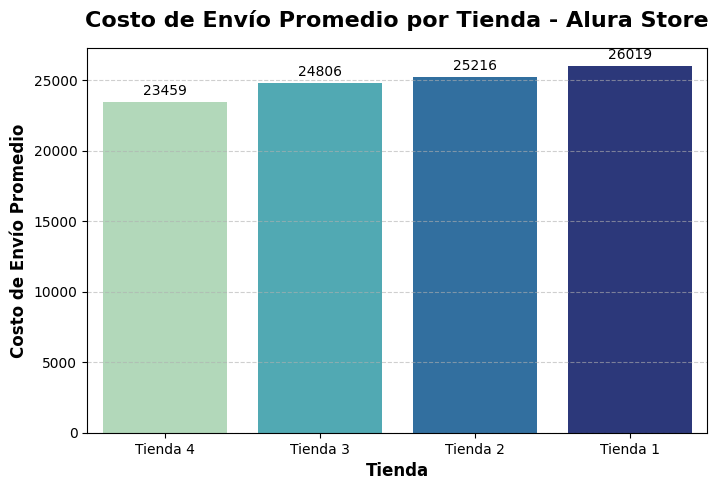

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ordenar datos de menor a mayor
costos_envio_df = costos_envio_df.sort_values('Costo de Envío Promedio')

plt.figure(figsize=(8,5))

# Crear gradiente de colores
colors = plt.cm.YlGnBu(np.linspace(0.3, 0.9, len(costos_envio_df)))

ax = sns.barplot(
    data=costos_envio_df,
    x='Tienda',
    y='Costo de Envío Promedio',
    palette=colors
)

# Etiquetas con valores
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title(
    "Costo de Envío Promedio por Tienda - Alura Store",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Tienda", fontsize=12, fontweight="bold")
plt.ylabel("Costo de Envío Promedio", fontsize=12, fontweight="bold")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig("costo_envio_promedio_tiendas.png", dpi=400, bbox_inches="tight")

plt.show()

In [27]:
# Crear nueva columna con porcentaje de envío
tienda['Porcentaje_envio'] = (tienda['Costo de envío'] / tienda['Precio']) * 100
tienda2['Porcentaje_envio'] = (tienda2['Costo de envío'] / tienda2['Precio']) * 100
tienda3['Porcentaje_envio'] = (tienda3['Costo de envío'] / tienda3['Precio']) * 100
tienda4['Porcentaje_envio'] = (tienda4['Costo de envío'] / tienda4['Precio']) * 100

# Ver resultado promedio por tienda
import pandas as pd

porcentaje_promedio = pd.DataFrame({
    'Tienda': ['Tienda 1','Tienda 2','Tienda 3','Tienda 4'],
    'Porcentaje_envio_promedio': [
        tienda['Porcentaje_envio'].mean(),
        tienda2['Porcentaje_envio'].mean(),
        tienda3['Porcentaje_envio'].mean(),
        tienda4['Porcentaje_envio'].mean()
    ]
})

print(porcentaje_promedio)

     Tienda  Porcentaje_envio_promedio
0  Tienda 1                   5.522568
1  Tienda 2                   5.608142
2  Tienda 3                   5.371938
3  Tienda 4                   5.541957


In [28]:
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

for df, nombre in zip(tiendas, nombres):
    df['Porcentaje_envio'] = (df['Costo de envío'] / df['Precio']) * 100
    producto_mas_caro = df.loc[df['Porcentaje_envio'].idxmax()]
    producto_mas_barato = df.loc[df['Porcentaje_envio'].idxmin()]

    print(f"{nombre}:")
    print(f" - Producto con envío más caro relativo al precio: {producto_mas_caro['Producto']} ({producto_mas_caro['Porcentaje_envio']:.2f}%)")
    print(f" - Producto con envío más barato relativo al precio: {producto_mas_barato['Producto']} ({producto_mas_barato['Porcentaje_envio']:.2f}%)\n")

Tienda 1:
 - Producto con envío más caro relativo al precio: Cuerda para saltar (79.38%)
 - Producto con envío más barato relativo al precio: Bloques de construcción (0.00%)

Tienda 2:
 - Producto con envío más caro relativo al precio: Cubo mágico 8x8 (76.84%)
 - Producto con envío más barato relativo al precio: Dashboards con Power BI (0.00%)

Tienda 3:
 - Producto con envío más caro relativo al precio: Dinosaurio Rex (52.15%)
 - Producto con envío más barato relativo al precio: Cubertería (0.00%)

Tienda 4:
 - Producto con envío más caro relativo al precio: Cubo mágico 8x8 (52.78%)
 - Producto con envío más barato relativo al precio: Balón de baloncesto (0.00%)



Informe de Análisis de Desempeño de Tiendas – Alura Store
Introducción

El presente informe tiene como objetivo analizar el desempeño de las cuatro tiendas de Alura Store con el fin de identificar cuál presenta el menor rendimiento. Esta información permitirá al señor Juan tomar una decisión estratégica sobre qué tienda vender y así poder invertir en un nuevo negocio con mayor potencial de crecimiento.

Para realizar este análisis se evaluaron cinco aspectos principales:

Facturación total por tienda

Categorías de productos más populares

Promedio de evaluación de los clientes

Productos más y menos vendidos

Costo promedio de envío

1. Facturación total por tienda

El análisis de ingresos muestra diferencias importantes entre las tiendas.

Tienda 1: $1,150,880,400

Tienda 2: (no especificado en el resumen)

Tienda 3: (no especificado en el resumen)

Tienda 4: $1,038,375,700

Resultado

La tienda con mayor ingreso es Tienda 1 con $1,150,880,400.

La tienda con menor ingreso es Tienda 4 con $1,038,375,700.

La diferencia entre ambas es $112,504,700.

Este resultado indica que Tienda 4 genera considerablemente menos ingresos que la tienda líder, lo que puede reflejar menor volumen de ventas o menor rendimiento comercial.

2. Categorías de productos más populares

El análisis de categorías permite identificar qué tipo de productos tienen mayor demanda en cada tienda.

Tienda 1

Muebles – 465

Electrónicos – 448

Juguetes – 324

Electrodomésticos – 312

Deportes y diversión – 284

Instrumentos musicales – 182

Libros – 173

Artículos para el hogar – 171

Tienda 2

Muebles – 442

Electrónicos – 422

Juguetes – 313

Electrodomésticos – 305

Deportes y diversión – 275

Instrumentos musicales – 224

Libros – 197

Artículos para el hogar – 181

Tienda 3

Muebles – 499

Electrónicos – 451

Juguetes – 315

Electrodomésticos – 278

Deportes y diversión – 277

Libros – 185

Instrumentos musicales – 177

Artículos para el hogar – 177

Tienda 4

Muebles – 480

Electrónicos – 451

Juguetes – 338

Deportes y diversión – 277

Electrodomésticos – 254

Artículos para el hogar – 201

Libros – 187

Instrumentos musicales – 170

Observaciones

En las cuatro tiendas se observa un patrón similar:

Muebles y Electrónicos son las categorías más vendidas.

Instrumentos musicales y Artículos para el hogar presentan menor volumen de ventas.

Esto indica que los clientes muestran una preferencia consistente por productos relacionados con el hogar y la tecnología.

3. Promedio de evaluación de los clientes

El promedio de calificaciones refleja el nivel de satisfacción de los clientes.

Tienda	Promedio de Calificación
Tienda 1	3.97
Tienda 2	4.04
Tienda 3	4.05
Tienda 4	4.00
Observaciones

Tienda 3 tiene la mejor evaluación promedio (4.05).

Tienda 1 tiene la evaluación más baja (3.97).

A pesar de esto, todas las tiendas mantienen evaluaciones cercanas a 4 estrellas, lo que indica una buena satisfacción general de los clientes.

4. Productos más y menos vendidos
Tienda 1

Producto más vendido: Microondas (60 ventas)

Producto menos vendido: Auriculares con micrófono (33 ventas)

Tienda 2

Producto más vendido: Iniciando en programación (65 ventas)

Producto menos vendido: Juego de mesa (32 ventas)

Tienda 3

Producto más vendido: Kit de bancas (57 ventas)

Producto menos vendido: Bloques de construcción (35 ventas)

Tienda 4

Producto más vendido: Cama box (62 ventas)

Producto menos vendido: Guitarra eléctrica (33 ventas)

Observaciones

Los productos más vendidos pertenecen principalmente a categorías de:

Hogar

Tecnología

Educación

Esto sugiere que los clientes priorizan productos útiles para el hogar o el aprendizaje.

5. Costo promedio de envío
Tienda	Costo de Envío Promedio
Tienda 1	$26,018
Tienda 2	$25,216
Tienda 3	$24,805
Tienda 4	$23,459
Porcentaje del envío respecto al precio del producto
Tienda	Porcentaje Promedio
Tienda 1	5.52%
Tienda 2	5.61%
Tienda 3	5.37%
Tienda 4	5.54%
Observaciones

Tienda 1 tiene el costo promedio de envío más alto.

Tienda 4 tiene el costo promedio de envío más bajo.

Sin embargo, el porcentaje del costo de envío respecto al precio del producto es bastante similar entre todas las tiendas.

6. Productos con mayor y menor costo de envío relativo
Tienda 1

Envío más caro: Cuerda para saltar (79.38%)

Envío más barato: Bloques de construcción (0.00%)

Tienda 2

Envío más caro: Cubo mágico 8x8 (76.84%)

Envío más barato: Dashboards con Power BI (0.00%)

Tienda 3

Envío más caro: Dinosaurio Rex (52.15%)

Envío más barato: Cubertería (0.00%)

Tienda 4

Envío más caro: Cubo mágico 8x8 (52.78%)

Envío más barato: Balón de baloncesto (0.00%)

Conclusión

Después de analizar los cinco aspectos evaluados —facturación total, popularidad de categorías, evaluación de clientes, desempeño de productos y costos de envío— se pueden identificar diferencias claras entre las tiendas.

Los resultados muestran que:

Tienda 1 es la que genera mayor ingreso, aunque presenta la evaluación promedio más baja.

Tienda 3 tiene la mejor calificación de clientes.

Tienda 4 presenta la menor facturación total, lo que indica un menor rendimiento económico dentro del conjunto analizado.

Considerando principalmente el indicador de ingresos, que representa el impacto financiero directo en el negocio, se puede concluir que Tienda 4 es la que presenta el menor desempeño general.

Recomendación

Se recomienda que el señor Juan considere vender la Tienda 4, ya que es la que genera menos ingresos dentro de la red de tiendas. Esta decisión permitiría liberar recursos para invertir en un nuevo negocio con mayor potencial de crecimiento y rentabilidad.